In [1]:
import numpy as np
import pandas as pd

In [2]:
train_df= pd.read_csv('PubMed_200k_RCT/train.csv')
dev_df = pd.read_csv('PubMed_200k_RCT/dev.csv')
test_df = pd.read_csv('PubMed_200k_RCT/test.csv')
train_df.head()

,abstract_id,line_id,abstract_text,line_number,total_lines,target
0,24491034,24491034_0_11,The emergence of HIV as a chronic condition me...,0,11,BACKGROUND
1,24491034,24491034_1_11,This paper describes the design and evaluation...,1,11,BACKGROUND
2,24491034,24491034_2_11,This study is designed as a randomised control...,2,11,METHODS
3,24491034,24491034_3_11,The intervention group will participate in the...,3,11,METHODS
4,24491034,24491034_4_11,The program is based on self-efficacy theory a...,4,11,METHODS


In [3]:
train_df = train_df.dropna(subset=['abstract_text'])
print(train_df['abstract_text'].isna().sum())
print(dev_df['abstract_text'].isna().sum())
print(test_df['abstract_text'].isna().sum())
print(train_df.describe())
print(train_df.info())

0
0
0
        abstract_id   line_number   total_lines
count  2.211860e+06  2.211860e+06  2.211860e+06
mean   1.777430e+07  5.709641e+00  1.241928e+01
std    5.372625e+06  4.054368e+00  3.317234e+00
min    1.279170e+06  0.000000e+00  3.000000e+00
25%    1.282092e+07  2.000000e+00  1.000000e+01
50%    1.850567e+07  5.000000e+00  1.200000e+01
75%    2.234881e+07  8.000000e+00  1.400000e+01
max    2.652916e+07  5.000000e+01  5.100000e+01
<class 'pandas.core.frame.DataFrame'>
Index: 2211860 entries, 0 to 2211860
Data columns (total 6 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   abstract_id    int64 
 1   line_id        object
 2   abstract_text  object
 3   line_number    int64 
 4   total_lines    int64 
 5   target         object
dtypes: int64(3), object(3)
memory usage: 118.1+ MB
None


In [4]:
print(dev_df.describe())
print(dev_df.info())

        abstract_id   line_number   total_lines
count  2.893200e+04  28932.000000  28932.000000
mean   1.781278e+07      5.676172     12.352343
std    5.356084e+06      3.999521      3.176805
min    1.336526e+06      0.000000      4.000000
25%    1.287862e+07      2.000000     10.000000
50%    1.855817e+07      5.000000     12.000000
75%    2.239816e+07      8.000000     14.000000
max    2.643621e+07     27.000000     28.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28932 entries, 0 to 28931
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   abstract_id    28932 non-null  int64 
 1   line_id        28932 non-null  object
 2   abstract_text  28932 non-null  object
 3   line_number    28932 non-null  int64 
 4   total_lines    28932 non-null  int64 
 5   target         28932 non-null  object
dtypes: int64(3), object(3)
memory usage: 1.3+ MB
None


In [5]:
print(test_df.describe())
print(test_df.info())

        abstract_id   line_number   total_lines
count  2.949300e+04  29493.000000  29493.000000
mean   1.773442e+07      5.805344     12.610687
std    5.390987e+06      4.093325      3.279820
min    1.334248e+06      0.000000      4.000000
25%    1.273415e+07      2.000000     10.000000
50%    1.832493e+07      5.000000     12.000000
75%    2.236804e+07      9.000000     14.000000
max    2.642272e+07     27.000000     28.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29493 entries, 0 to 29492
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   abstract_id    29493 non-null  int64 
 1   line_id        29493 non-null  object
 2   abstract_text  29493 non-null  object
 3   line_number    29493 non-null  int64 
 4   total_lines    29493 non-null  int64 
 5   target         29493 non-null  object
dtypes: int64(3), object(3)
memory usage: 1.4+ MB
None


In [6]:
# # Drop the unneccassry column
train_df = train_df.drop(columns=['abstract_id', 'line_id'])
dev_df = dev_df.drop(columns=['abstract_id', 'line_id'])
# med_data_test = med_data_test.drop(columns=['abstract_id', 'line_id'])
dev_df.head()

,abstract_text,line_number,total_lines,target
0,Adrenergic activation is thought to be an impo...,0,9,BACKGROUND
1,Systemic venous norepinephrine was measured at...,1,9,RESULTS
2,Baseline norepinephrine level was associated w...,2,9,RESULTS
3,"On multivariate analysis , baseline norepineph...",3,9,RESULTS
4,"In contrast , the relation of the change in no...",4,9,RESULTS


In [7]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Shyam\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Shyam\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Shyam\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [8]:
X_train = train_df["abstract_text"].astype(str)
y_train = train_df["target"]

X_val = dev_df["abstract_text"].astype(str)
y_val = dev_df["target"]

X_test = test_df["abstract_text"].astype(str)
y_test = test_df["target"]

In [9]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text

In [10]:
X_train = X_train.apply(clean_text)
X_val   = X_val.apply(clean_text)
X_test  = X_test.apply(clean_text)

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=80000,
    stop_words="english",
    sublinear_tf=True
)

X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec   = vectorizer.transform(X_val)
X_test_vec  = vectorizer.transform(X_test)

In [12]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_vec, y_train)

,alpha,0.1
,force_alpha,True
,fit_prior,True
,class_prior,None


In [13]:
from sklearn.metrics import accuracy_score

y_pred = nb_model.predict(X_test_vec)
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.7665


In [14]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

  BACKGROUND       0.60      0.49      0.54      2663
 CONCLUSIONS       0.66      0.69      0.67      4426
     METHODS       0.82      0.85      0.84      9751
   OBJECTIVE       0.65      0.56      0.60      2377
     RESULTS       0.81      0.84      0.83     10276

    accuracy                           0.77     29493
   macro avg       0.71      0.68      0.69     29493
weighted avg       0.76      0.77      0.76     29493



In [15]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(y_test, y_pred, labels=nb_model.classes_)
cm_df = pd.DataFrame(cm, index=nb_model.classes_, columns=nb_model.classes_)
print(cm_df)

             BACKGROUND  CONCLUSIONS  METHODS  OBJECTIVE  RESULTS
BACKGROUND         1299          541      243        477      103
CONCLUSIONS         285         3035      202        102      802
METHODS             107          201     8331        117      995
OBJECTIVE           423          280      289       1321       64
RESULTS              67          514     1049         26     8620


In [16]:
errors = test_df.copy()
errors["prediction"] = y_pred

misclassified = errors[errors["target"] != errors["prediction"]]
misclassified.head(10)

,abstract_id,line_id,abstract_text,line_number,total_lines,target,prediction
3,24562799,24562799_3_11,"In addition , we compared plasma levels of MAp...",3,11,BACKGROUND,RESULTS
4,24562799,24562799_4_11,A total of 192 MI patients and 140 control per...,4,11,METHODS,RESULTS
10,24562799,24562799_10_11,"Plasma levels of MAp44 , MASP-1 , and MASP-3 a...",10,11,CONCLUSIONS,RESULTS
25,7848884,7848884_7_13,In this study failures ( > 3 vomiting ) were r...,7,13,RESULTS,METHODS
32,18492267,18492267_1_13,We conducted a randomized study comparing thes...,1,13,BACKGROUND,METHODS
41,18492267,18492267_10_13,"In our cohort of patients , the use of SA was ...",10,13,CONCLUSIONS,RESULTS
51,15108607,15108607_7_10,In this study it was possible to measure the e...,7,10,CONCLUSIONS,OBJECTIVE
52,15108607,15108607_8_10,The auricular area we chose for stimulation wa...,8,10,CONCLUSIONS,METHODS
53,15108607,15108607_9_10,Acupuncture and needle contact for 10 seconds ...,9,10,CONCLUSIONS,RESULTS
57,17064200,17064200_3_14,Four hundred sixty-three patients with a diagn...,3,14,METHODS,RESULTS


In [17]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    ngram_range=(1, 3),
    max_features=80000,
    min_df=2
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

In [18]:
from sklearn.naive_bayes import ComplementNB
model = ComplementNB(alpha=0.5)
model.fit(X_train_vec, y_train)

,alpha,0.5
,force_alpha,True
,fit_prior,True
,class_prior,None
,norm,False


In [19]:
print("a " + "  Accuracy_Score")
for a in [0.01, 0.05, 0.1, 0.5, 1.0]:
    model = ComplementNB(alpha=a)
    model.fit(X_train_vec, y_train)
    preds = model.predict(X_test_vec)
    print(a, accuracy_score(y_test, preds))
    print("/n")
    print(classification_report(y_test, preds))

a   Accuracy_Score
0.01 0.7969348659003831
/n
              precision    recall  f1-score   support

  BACKGROUND       0.68      0.45      0.54      2663
 CONCLUSIONS       0.68      0.74      0.71      4426
     METHODS       0.85      0.90      0.87      9751
   OBJECTIVE       0.66      0.65      0.65      2377
     RESULTS       0.85      0.85      0.85     10276

    accuracy                           0.80     29493
   macro avg       0.74      0.72      0.72     29493
weighted avg       0.79      0.80      0.79     29493

0.05 0.7969009595497236
/n
              precision    recall  f1-score   support

  BACKGROUND       0.68      0.45      0.54      2663
 CONCLUSIONS       0.68      0.74      0.71      4426
     METHODS       0.85      0.90      0.87      9751
   OBJECTIVE       0.66      0.65      0.65      2377
     RESULTS       0.85      0.85      0.85     10276

    accuracy                           0.80     29493
   macro avg       0.74      0.72      0.72     29493
weig

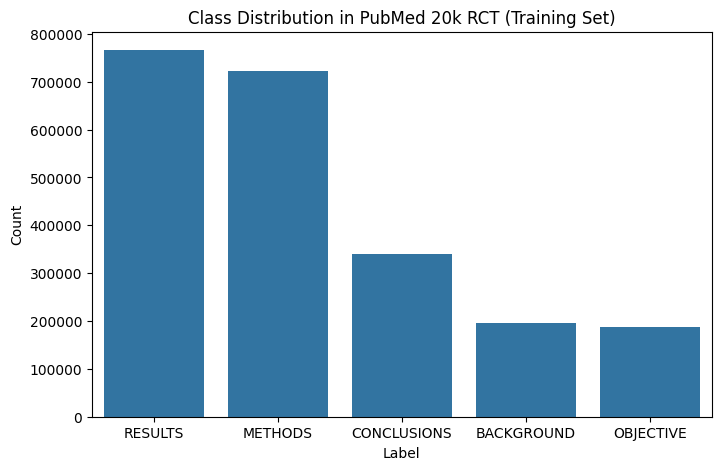

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x=y_train, order=y_train.value_counts().index)
plt.title("Class Distribution in PubMed 20k RCT (Training Set)")
plt.ylabel("Count")
plt.xlabel("Label")
plt.show()

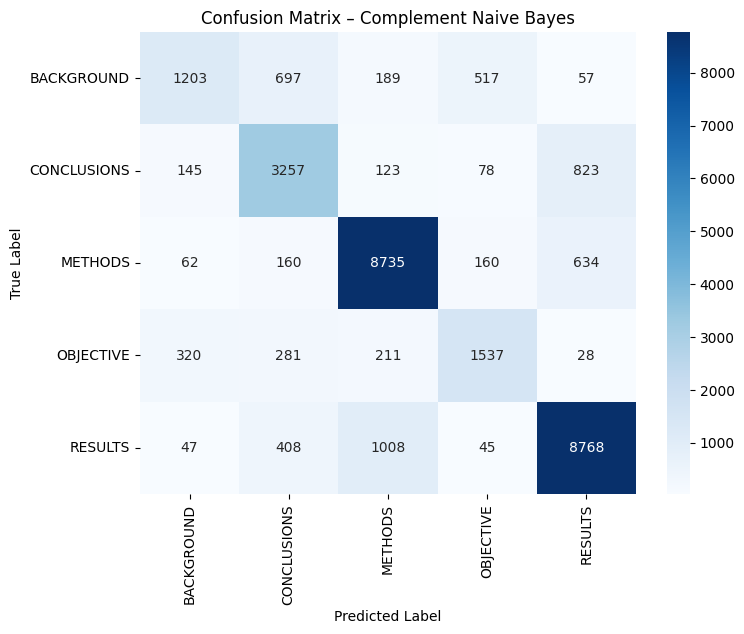

In [21]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(y_test, preds, labels=model.classes_)
cm_df = pd.DataFrame(cm, index=model.classes_, columns=model.classes_)

plt.figure(figsize=(8,6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix – Complement Naive Bayes")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

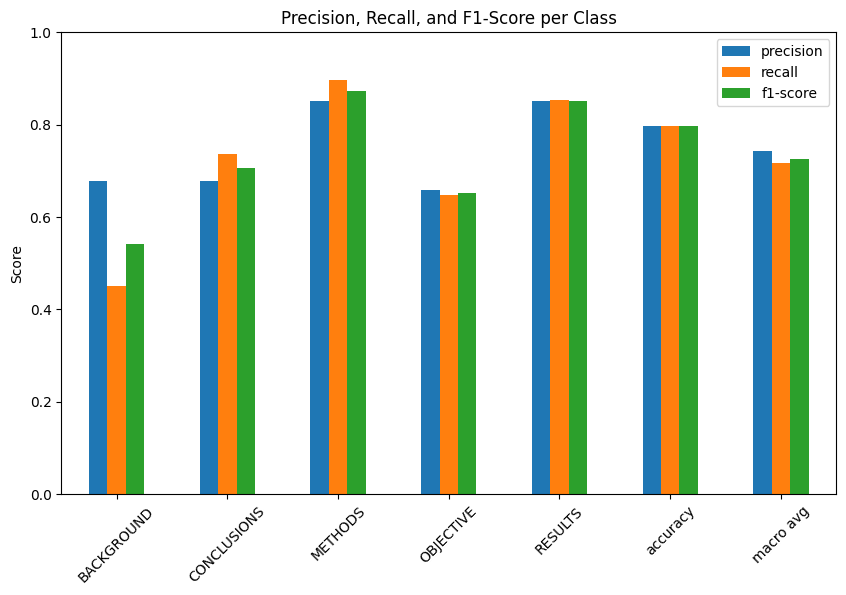

In [22]:
from sklearn.metrics import classification_report

report = classification_report(y_test, preds, output_dict=True)
report_df = pd.DataFrame(report).transpose()

report_df.iloc[:-1, :3].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Precision, Recall, and F1-Score per Class")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.show()


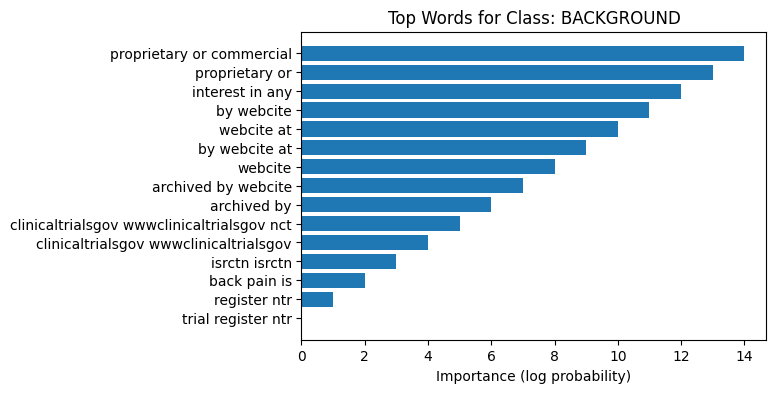

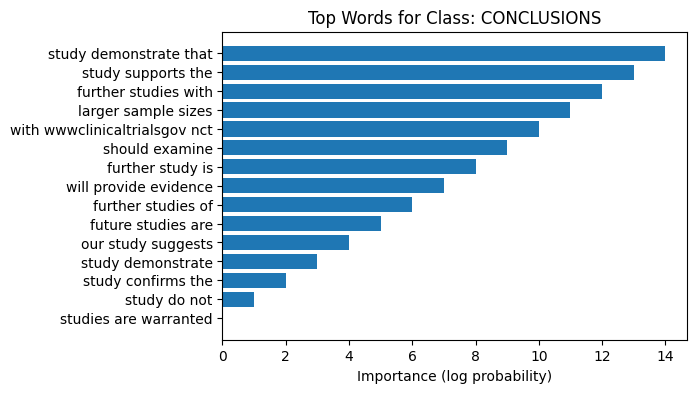

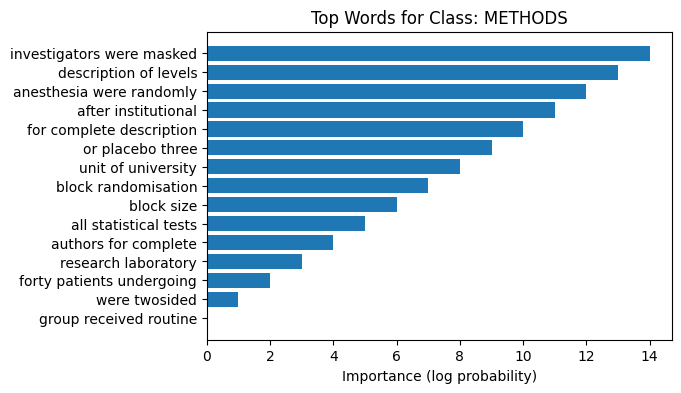

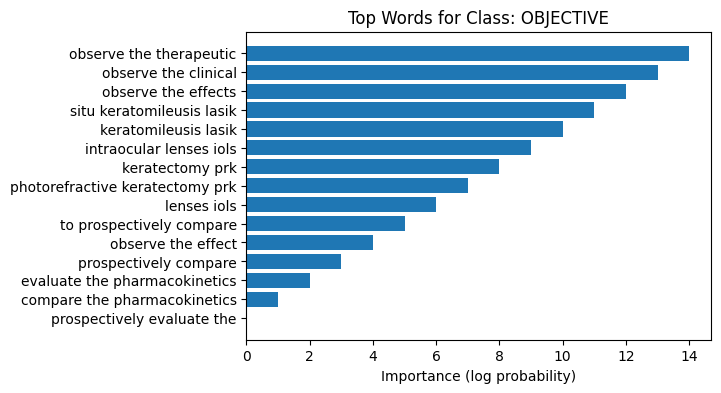

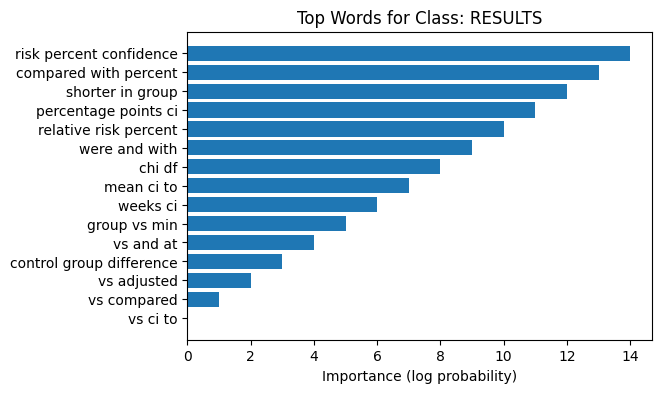

In [23]:
import numpy as np

feature_names = np.array(vectorizer.get_feature_names_out())

for i, label in enumerate(model.classes_):
    top_words = feature_names[
        np.argsort(model.feature_log_prob_[i])[-15:]
    ]
    
    plt.figure(figsize=(6,4))
    plt.barh(top_words, range(len(top_words)))
    plt.title(f"Top Words for Class: {label}")
    plt.xlabel("Importance (log probability)")
    plt.show()

In [25]:

import joblib

joblib.dump(model, "nb_model.pkl")
model = joblib.load("nb_model.pkl")